In [ ]:
# Install required packages
# Gerekli paketlerin kurulumu
!pip install -q albumentations timm openpyxl

# Mount Google Drive
# Google Drive baglama
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
import os

# Path configuration
# Yol yapilandirmasi
# NOTE: adjust these paths to your own Drive structure
# NOT: bu yollari kendi Drive yapina gore duzenle
DATA_ROOT = "/content/drive/MyDrive/mini_dataset_2000"  # a/b/c/d klasorlerinin bulundugu ana dizin
OUTPUT_ROOT = "/content/drive/MyDrive/breast_density/outputs"  # ciktilarin kaydedilecegi dizin

# Create output directory if not exists
# Cikti dizini yoksa olustur
os.makedirs(OUTPUT_ROOT, exist_ok=True)

# Class folder names
# Sinif klasor isimleri
CLASSES = ["a", "b", "c", "d"]

# Verify data root exists
# Veri dizininin varligini dogrula
assert os.path.exists(DATA_ROOT), f"DATA_ROOT bulunamadi: {DATA_ROOT}"
print("Veri dizini bulundu:", DATA_ROOT)
print("Alt klasorler:", os.listdir(DATA_ROOT))

Veri dizini bulundu: /content/drive/MyDrive/mini_dataset_2000
Alt klasorler: ['a', 'b', 'c', 'd']


In [ ]:
import re
import pandas as pd

# Parse filename into components
# Dosya adini bilesenlerine ayir
# Expected format: {ID}_{SIDE}{VIEW}.png  e.g. 845285916_RCC.png, 845285916_LMLO.png
# Beklenen format: {ID}_{TARAF}{GORUNUM}.png
def parse_filename(fname):
    # Remove extension
    # Uzantiyi kaldir
    base = os.path.splitext(fname)[0]
    # Split by underscore: ID and the rest
    # Alt tireden ayir: ID ve geri kalan
    parts = base.split("_")
    if len(parts) != 2:
        return None
    patient_id = parts[0]
    view_code = parts[1].upper()  # RCC, LMLO, LCC, RMLO
    # Side is first char, view is the rest
    # Taraf ilk karakter, gorunum geri kalan
    side = view_code[0]        # L or R
    view = view_code[1:]       # CC or MLO
    if side not in ["L", "R"] or view not in ["CC", "MLO"]:
        return None
    return patient_id, side, view

# Scan all class folders and build a dataframe
# Tum sinif klasorlerini tara ve tablo olustur
rows = []
for label in CLASSES:
    class_dir = os.path.join(DATA_ROOT, label)
    if not os.path.isdir(class_dir):
        print(f"Uyari: {class_dir} bulunamadi, atlaniyor")
        continue
    for fname in os.listdir(class_dir):
        if not fname.lower().endswith(".png"):
            continue
        parsed = parse_filename(fname)
        if parsed is None:
            print(f"Ayristirilamadi: {fname}")
            continue
        patient_id, side, view = parsed
        rows.append({
            "patient_id": patient_id,
            "side": side,
            "view": view,
            "label": label,
            "filename": fname,
            "filepath": os.path.join(class_dir, fname),
        })

df = pd.DataFrame(rows)
print("Toplam gorunulen goruntu sayisi:", len(df))
df.head(10)

Toplam gorunulen goruntu sayisi: 8000


,patient_id,side,view,label,filename,filepath
0,836194731,R,MLO,a,836194731_RMLO.png,/content/drive/MyDrive/mini_dataset_2000/a/836...
1,836194731,L,CC,a,836194731_LCC.png,/content/drive/MyDrive/mini_dataset_2000/a/836...
2,836194731,L,MLO,a,836194731_LMLO.png,/content/drive/MyDrive/mini_dataset_2000/a/836...
3,836194731,R,CC,a,836194731_RCC.png,/content/drive/MyDrive/mini_dataset_2000/a/836...
4,845280431,L,CC,a,845280431_LCC.png,/content/drive/MyDrive/mini_dataset_2000/a/845...
5,845280431,R,CC,a,845280431_RCC.png,/content/drive/MyDrive/mini_dataset_2000/a/845...
6,845280431,L,MLO,a,845280431_LMLO.png,/content/drive/MyDrive/mini_dataset_2000/a/845...
7,845280431,R,MLO,a,845280431_RMLO.png,/content/drive/MyDrive/mini_dataset_2000/a/845...
8,845280451,L,MLO,a,845280451_LMLO.png,/content/drive/MyDrive/mini_dataset_2000/a/845...
9,845280451,R,CC,a,845280451_RCC.png,/content/drive/MyDrive/mini_dataset_2000/a/845...


In [ ]:
# Basic distributions
# Temel dagilimlar
print("* Sinif dagilimi (goruntu bazli)")
print(df["label"].value_counts())
print()

print("* Taraf dagilimi")
print(df["side"].value_counts())
print()

print("* Gorunum dagilimi")
print(df["view"].value_counts())
print()

print("* Benzersiz hasta sayisi")
print(df["patient_id"].nunique())
print()

# Group by breast (patient_id + side) and check which views exist
# Meme bazli grupla (hasta + taraf) ve hangi gorunumler var kontrol et
breast_group = df.groupby(["patient_id", "side"])["view"].apply(set).reset_index()
breast_group["has_CC"] = breast_group["view"].apply(lambda s: "CC" in s)
breast_group["has_MLO"] = breast_group["view"].apply(lambda s: "MLO" in s)
breast_group["complete"] = breast_group["has_CC"] & breast_group["has_MLO"]

print("* Meme bazli (breast-level) analiz")
print("Toplam meme sayisi:", len(breast_group))
print("Tam (CC+MLO) olan meme sayisi:", breast_group["complete"].sum())
print("Eksik gorunumlu meme sayisi:", (~breast_group["complete"]).sum())
print()

print("Eksik durumlarin detayi:")
incomplete = breast_group[~breast_group["complete"]]
print("Sadece CC olan:", (incomplete["has_CC"] & ~incomplete["has_MLO"]).sum())
print("Sadece MLO olan:", (~incomplete["has_CC"] & incomplete["has_MLO"]).sum())

* Sinif dagilimi (goruntu bazli)
label
b    2828
c    2796
d    1388
a     988
Name: count, dtype: int64

* Taraf dagilimi
side
R    4000
L    4000
Name: count, dtype: int64

* Gorunum dagilimi
view
MLO    4000
CC     4000
Name: count, dtype: int64

* Benzersiz hasta sayisi
2000

* Meme bazli (breast-level) analiz
Toplam meme sayisi: 4000
Tam (CC+MLO) olan meme sayisi: 4000
Eksik gorunumlu meme sayisi: 0

Eksik durumlarin detayi:
Sadece CC olan: 0
Sadece MLO olan: 0


In [ ]:
# Check label consistency per breast
# Meme bazli etiket tutarliligini kontrol et
# A breast (patient_id + side) should have a single density label across its views
# Bir memenin (hasta + taraf) tum gorunumleri ayni yogunluk etiketine sahip olmali
breast_labels = df.groupby(["patient_id", "side"])["label"].apply(set).reset_index()
breast_labels["n_labels"] = breast_labels["label"].apply(len)

inconsistent = breast_labels[breast_labels["n_labels"] > 1]
print("Birden fazla etikete sahip meme sayisi:", len(inconsistent))
if len(inconsistent) > 0:
    print("DIKKAT: Ayni memenin gorunumleri farkli siniflarda!")
    print(inconsistent.head(20))
else:
    print("Tum memeler tutarli tek etikete sahip.")

Birden fazla etikete sahip meme sayisi: 0
Tum memeler tutarli tek etikete sahip.


In [ ]:
# Build breast-level dataframe: one row per breast with both view paths
# Meme bazli tablo olustur: her satir bir meme, iki gorunum yolu ile
# Each breast = (patient_id, side), has one CC and one MLO path
# Her meme = (hasta, taraf), bir CC ve bir MLO yoluna sahip

# Pivot views into columns
# Gorunumleri sutunlara cevir
breast_df = df.pivot_table(
    index=["patient_id", "side", "label"],
    columns="view",
    values="filepath",
    aggfunc="first"
).reset_index()

breast_df.columns.name = None
breast_df = breast_df.rename(columns={"CC": "cc_path", "MLO": "mlo_path"})

# Verify no missing paths
# Eksik yol olmadigini dogrula
assert breast_df["cc_path"].notna().all(), "Eksik CC yolu var!"
assert breast_df["mlo_path"].notna().all(), "Eksik MLO yolu var!"

# Map string labels to integer indices
# String etiketleri tam sayi indekslerine cevir
label_to_idx = {c: i for i, c in enumerate(CLASSES)}  # a:0, b:1, c:2, d:3
breast_df["label_idx"] = breast_df["label"].map(label_to_idx)

print("Toplam meme (ornek) sayisi:", len(breast_df))
print("\nMeme bazli sinif dagilimi:")
print(breast_df["label"].value_counts())
breast_df.head()

Toplam meme (ornek) sayisi: 4000

Meme bazli sinif dagilimi:
label
b    1414
c    1398
d     694
a     494
Name: count, dtype: int64


,patient_id,side,label,cc_path,mlo_path,label_idx
0,822670188,L,d,/content/drive/MyDrive/mini_dataset_2000/d/822...,/content/drive/MyDrive/mini_dataset_2000/d/822...,3
1,822670188,R,d,/content/drive/MyDrive/mini_dataset_2000/d/822...,/content/drive/MyDrive/mini_dataset_2000/d/822...,3
2,822670196,L,c,/content/drive/MyDrive/mini_dataset_2000/c/822...,/content/drive/MyDrive/mini_dataset_2000/c/822...,2
3,822670196,R,c,/content/drive/MyDrive/mini_dataset_2000/c/822...,/content/drive/MyDrive/mini_dataset_2000/c/822...,2
4,822670197,L,d,/content/drive/MyDrive/mini_dataset_2000/d/822...,/content/drive/MyDrive/mini_dataset_2000/d/822...,3


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold

# Grup-aware stratified split
# Group = patient_id (prevents leakage), stratify target = breast label
# Grup = hasta ID (sizintiyi onler), stratify hedefi = meme etiketi
SEED = 42
np.random.seed(SEED)

X = np.arange(len(breast_df))
y = breast_df["label_idx"].values
groups = breast_df["patient_id"].values

# First split: separate test (15%) from the rest (85%)
# Ilk bolme: test (%15) ile geri kalani (%85) ayir
# We use 1/tetst_fraction folds and take one fold as test
# test orani icin fold sayisi = 1/0.15 ~ 7, ama daha stabil olmasi icin iki asamali gidecegiz
sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
trainval_idx, test_idx = next(iter(sgkf.split(X, y, groups)))

# Second split: from trainval, separate val
# Ikinci bolme: trainval icinden val ayir
# val should be ~15% of total = ~17.6% of the 85% trainval
# val toplam ~%15 olmali = trainval'in ~%17.6'si
X_tv = trainval_idx
y_tv = y[trainval_idx]
groups_tv = groups[trainval_idx]

sgkf2 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED)
tr_rel_idx, val_rel_idx = next(iter(sgkf2.split(X_tv, y_tv, groups_tv)))

train_idx = trainval_idx[tr_rel_idx]
val_idx = trainval_idx[val_rel_idx]

# Assign split column
# Split sutunu ata
breast_df["split"] = "train"
breast_df.loc[test_idx, "split"] = "test"
breast_df.loc[val_idx, "split"] = "val"

print("Split boyutlari:")
print(breast_df["split"].value_counts())
print("\nOranlar:")
print((breast_df["split"].value_counts() / len(breast_df) * 100).round(1))

Split boyutlari:
split
train    2856
val       572
test      572
Name: count, dtype: int64

Oranlar:
split
train    71.4
val      14.3
test     14.3
Name: count, dtype: float64


In [ ]:
# Verify no patient leakage across splits
# Setler arasi hasta sizintisi olmadigini dogrula
train_patients = set(breast_df[breast_df["split"] == "train"]["patient_id"])
val_patients = set(breast_df[breast_df["split"] == "val"]["patient_id"])
test_patients = set(breast_df[breast_df["split"] == "test"]["patient_id"])

print("* Hasta sizintisi kontrolu")
print("Train-Val kesisim:", len(train_patients & val_patients))
print("Train-Test kesisim:", len(train_patients & test_patients))
print("Val-Test kesisim:", len(val_patients & test_patients))
assert len(train_patients & val_patients) == 0, "Train-Val sizintisi!"
assert len(train_patients & test_patients) == 0, "Train-Test sizintisi!"
assert len(val_patients & test_patients) == 0, "Val-Test sizintisi!"
print("Sizinti yok, dogrulandi.")

# Check class distribution preserved across splits
# Sinif dagiliminin korundugunu kontrol et
print("\n* Split bazli sinif dagilimi (%)")
dist = breast_df.groupby("split")["label"].value_counts(normalize=True).unstack() * 100
print(dist.round(1))

# Save split assignment to Drive for reproducibility
# Yeniden uretilebilirlik icin split atamasini Drive'a kaydet
split_save_path = os.path.join(OUTPUT_ROOT, "breast_split.csv")
breast_df.to_csv(split_save_path, index=False)
print(f"\nSplit kaydedildi: {split_save_path}")

* Hasta sizintisi kontrolu
Train-Val kesisim: 0
Train-Test kesisim: 0
Val-Test kesisim: 0
Sizinti yok, dogrulandi.

* Split bazli sinif dagilimi (%)
label     a     b     c     d
split                        
test   12.6  33.6  37.1  16.8
train  12.5  35.6  34.6  17.3
val    11.2  36.0  34.6  18.2

Split kaydedildi: /content/drive/MyDrive/breast_density/outputs/breast_split.csv


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# Input image size
# Giris goruntu boyutu
IMG_SIZE = 512

# ImageNet normalization stats
# ImageNet normalizasyon degerleri
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training augmentation (medium, anatomy-aware)
# Egitim augmentation (orta, anatomiye duyarli)
# VerticalFlip removed: mammograms have fixed anatomical orientation
# VerticalFlip kaldirildi: mamogramlarin sabit anatomik yonelimi vardir
# Rotation reduced to 15 deg to keep images realistic
# Rotasyon 15 dereceye dusuruldu, goruntuler gercekci kalsin
# Brightness/contrast softened to avoid overly dark samples
# Brightness/contrast yumusatildi, asiri koyu ornekler onlensin
# NOTE: corner 'L' annotations left untouched for now; will revisit with Grad-CAM after baseline
# NOT: kosedeki 'L' annotasyonlari simdilik birakildi; baseline sonrasi Grad-CAM ile tekrar bakilacak
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.0625,
        scale_limit=0.1,
        rotate_limit=15,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.08,
        contrast_limit=0.12,
        p=0.3
    ),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

# Validation / test transform (no augmentation)
# Dogrulama / test transform (augmentation yok)
eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

print("Transformlar hazir.")

Transformlar hazir.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
import torch
from torch.utils.data import Dataset

class BreastDensityDataset(Dataset):
    # Two-view breast density dataset
    # Iki gorunumlu meme yogunlugu veri seti
    # Each sample returns (cc_image, mlo_image, label)
    # Her ornek (cc_goruntu, mlo_goruntu, etiket) dondurur

    def __init__(self, dataframe, transform):
        # Filter to the given split dataframe
        # Verilen split tablosuna gore filtrele
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _load_image(self, path):
        # Read grayscale image and convert to 3-channel
        # Gri tonlamali goruntuyu oku ve 3 kanala cevir
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Goruntu okunamadi: {path}")
        # Duplicate single channel to 3 channels for ImageNet backbone
        # ImageNet omurgasi icin tek kanali 3 kanala kopyala
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        cc_img = self._load_image(row["cc_path"])
        mlo_img = self._load_image(row["mlo_path"])

        # Apply the same transform type to both views independently
        # Her iki gorunume ayni transform turunu bagimsiz uygula
        cc_img = self.transform(image=cc_img)["image"]
        mlo_img = self.transform(image=mlo_img)["image"]

        label = int(row["label_idx"])
        return cc_img, mlo_img, label

print("Dataset sinifi tanimlandi.")

Dataset sinifi tanimlandi.


In [ ]:
from torch.utils.data import DataLoader

# Batch size for 512x512 two-view on T4
# T4 uzerinde 512x512 iki gorunum icin batch boyutu
# Start conservative to avoid OOM; increase later if memory allows
# OOM'dan kacinmak icin dusuk basla; bellek izin verirse artir
BATCH_SIZE = 8
NUM_WORKERS = 2

# Split dataframes
# Split tablolari
train_df = breast_df[breast_df["split"] == "train"].copy()
val_df = breast_df[breast_df["split"] == "val"].copy()
test_df = breast_df[breast_df["split"] == "test"].copy()

# Datasets
# Veri setleri
train_ds = BreastDensityDataset(train_df, train_transform)
val_ds = BreastDensityDataset(val_df, eval_transform)
test_ds = BreastDensityDataset(test_df, eval_transform)

# DataLoaders
# Veri yukleyiciler
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print("DataLoader'lar hazir.")
print(f"Train batch sayisi: {len(train_loader)}")
print(f"Val batch sayisi: {len(val_loader)}")
print(f"Test batch sayisi: {len(test_loader)}")

# Quick sanity check on one batch
# Bir batch uzerinde hizli kontrol
cc, mlo, lbl = next(iter(train_loader))
print(f"\nCC batch sekli: {cc.shape}")
print(f"MLO batch sekli: {mlo.shape}")
print(f"Etiket batch sekli: {lbl.shape}")
print(f"Etiket ornegi: {lbl[:8].tolist()}")

NameError: name 'breast_df' is not defined

Ornek meme: hasta 822670197, taraf L, etiket d


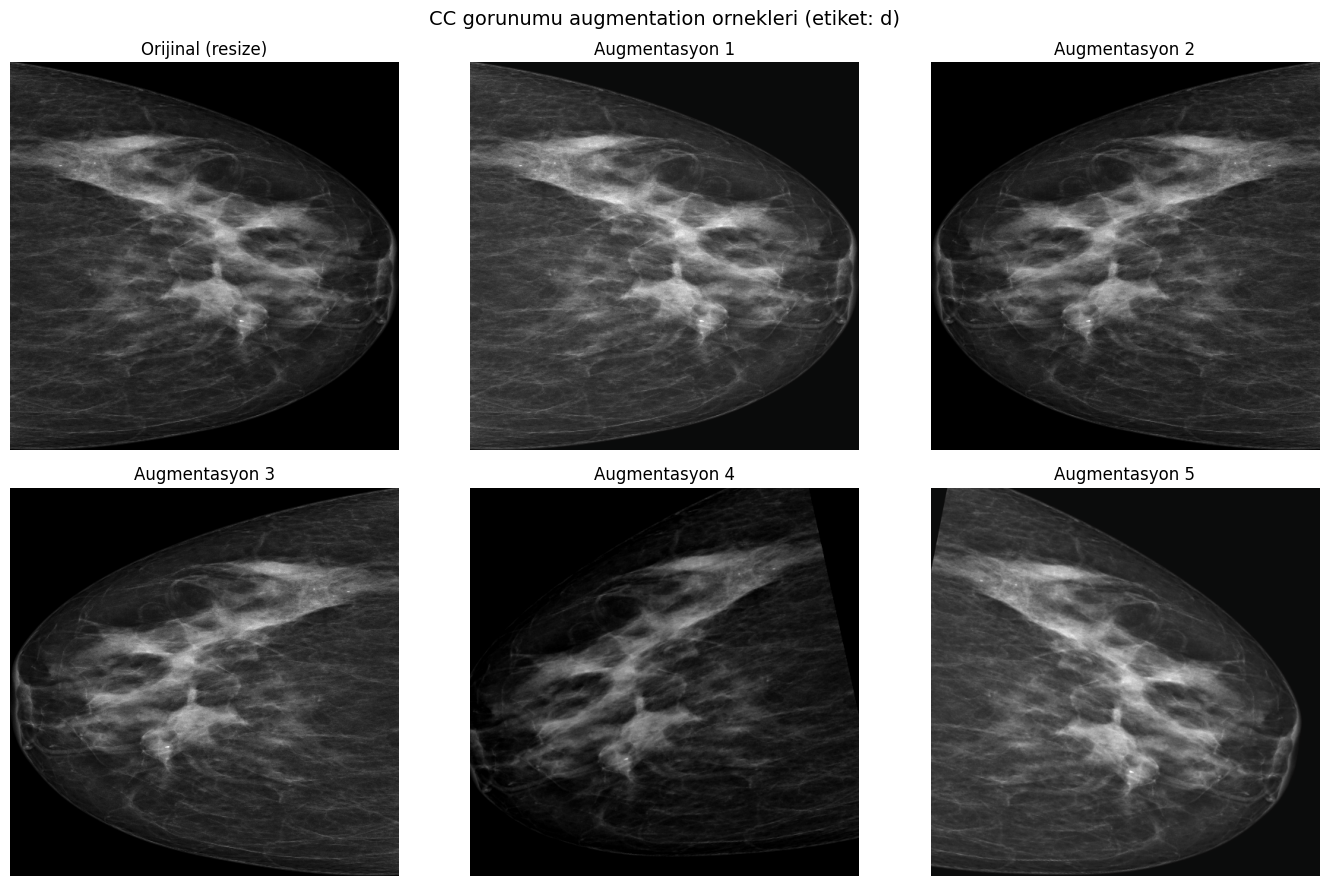

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Denormalize a tensor image for display
# Goruntuyu gostermek icin normalizasyonu geri cevir
def denormalize(tensor):
    mean = np.array(IMAGENET_MEAN)
    std = np.array(IMAGENET_STD)
    # Tensor: C,H,W -> H,W,C
    img = tensor.permute(1, 2, 0).cpu().numpy()
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img

# Pick one breast from training set
# Egitim setinden bir meme sec
sample_row = train_df.iloc[0]
print(f"Ornek meme: hasta {sample_row['patient_id']}, taraf {sample_row['side']}, etiket {sample_row['label']}")

# Load raw CC image
# Ham CC goruntusunu yukle
raw_cc = cv2.imread(sample_row["cc_path"], cv2.IMREAD_GRAYSCALE)
raw_cc = cv2.cvtColor(raw_cc, cv2.COLOR_GRAY2RGB)

# Show original + 5 augmented versions
# Orijinal + 5 augmente edilmis versiyon goster
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

# Original (only resize + normalize, then denormalize)
# Orijinal (sadece resize + normalize, sonra geri cevir)
orig = eval_transform(image=raw_cc)["image"]
axes[0].imshow(denormalize(orig))
axes[0].set_title("Orijinal (resize)")
axes[0].axis("off")

# 5 augmented versions
# 5 augmente versiyon
for i in range(1, 6):
    aug = train_transform(image=raw_cc)["image"]
    axes[i].imshow(denormalize(aug))
    axes[i].set_title(f"Augmentasyon {i}")
    axes[i].axis("off")

plt.suptitle(f"CC gorunumu augmentation ornekleri (etiket: {sample_row['label']})", fontsize=14)
plt.tight_layout()
plt.show()

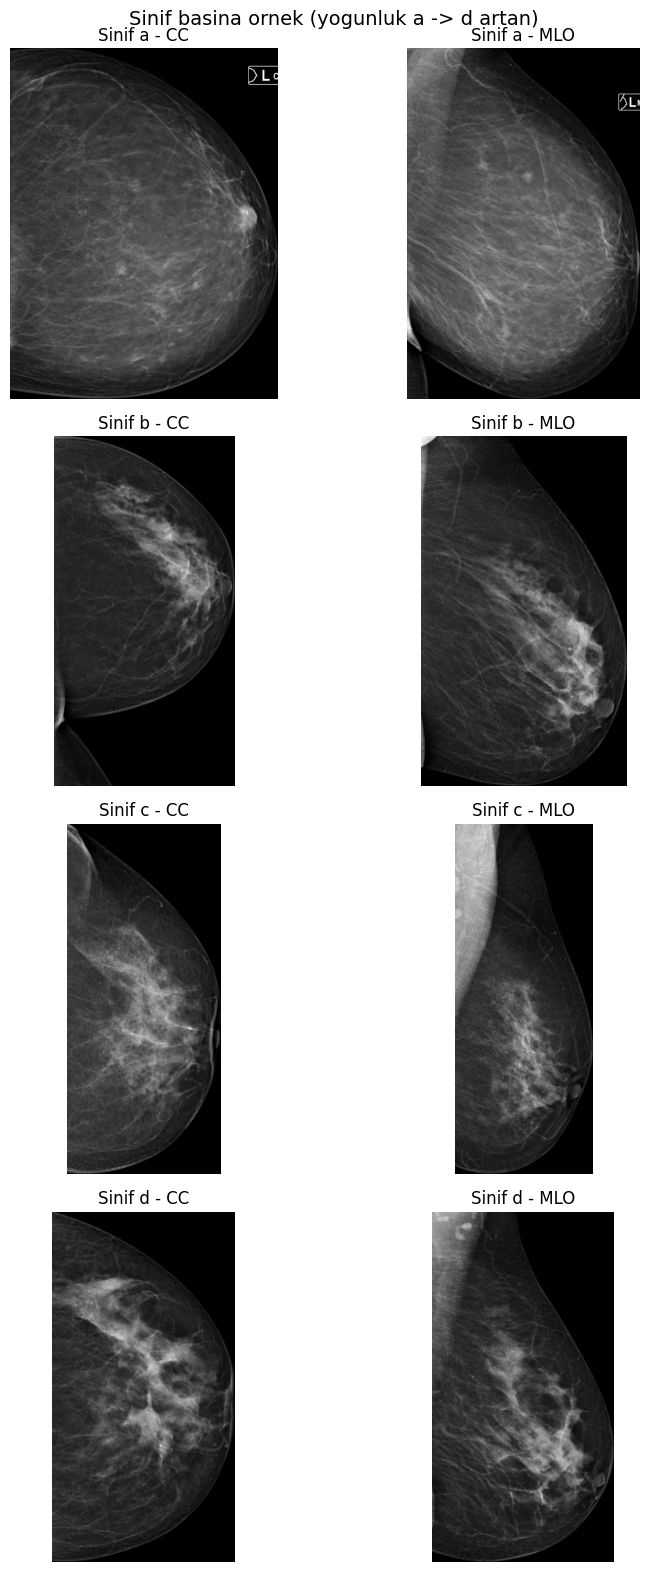

In [ ]:
# Show one CC+MLO pair per class
# Her siniftan bir CC+MLO cifti goster
fig, axes = plt.subplots(len(CLASSES), 2, figsize=(9, 4 * len(CLASSES)))

for row_i, cls in enumerate(CLASSES):
    # Get first breast of this class from train set
    # Egitim setinden bu sinifin ilk memesini al
    cls_row = train_df[train_df["label"] == cls].iloc[0]

    cc = cv2.imread(cls_row["cc_path"], cv2.IMREAD_GRAYSCALE)
    mlo = cv2.imread(cls_row["mlo_path"], cv2.IMREAD_GRAYSCALE)

    axes[row_i, 0].imshow(cc, cmap="gray")
    axes[row_i, 0].set_title(f"Sinif {cls} - CC")
    axes[row_i, 0].axis("off")

    axes[row_i, 1].imshow(mlo, cmap="gray")
    axes[row_i, 1].set_title(f"Sinif {cls} - MLO")
    axes[row_i, 1].axis("off")

plt.suptitle("Sinif basina ornek (yogunluk a -> d artan)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class TwoViewDensityNet(nn.Module):
    # Two-view breast density classifier
    # Iki gorunumlu meme yogunlugu siniflandiricisi
    # Two ResNet-50 branches (CC and MLO), features concatenated then classified
    # Iki ResNet-50 dali (CC ve MLO), oznitelikler birlestirilip siniflandirilir

    def __init__(self, num_classes=4, pretrained=True):
        super().__init__()

        # CC branch: ResNet-50 without final FC
        # CC dali: son FC katmani olmadan ResNet-50
        cc_backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        )
        self.cc_features = nn.Sequential(*list(cc_backbone.children())[:-1])

        # MLO branch: separate ResNet-50 without final FC
        # MLO dali: ayri, son FC katmani olmadan ResNet-50
        mlo_backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        )
        self.mlo_features = nn.Sequential(*list(mlo_backbone.children())[:-1])

        # ResNet-50 outputs 2048-dim vector per branch after GAP
        # ResNet-50 her dalda GAP sonrasi 2048 boyutlu vektor uretir
        feat_dim = 2048

        # Classifier over concatenated features (2048 + 2048 = 4096)
        # Birlestirilmis oznitelikler uzerinde siniflandirici (4096)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(feat_dim * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, cc, mlo):
        # Extract features from each view
        # Her gorunumden oznitelik cikar
        cc_feat = self.cc_features(cc)      # B, 2048, 1, 1
        mlo_feat = self.mlo_features(mlo)   # B, 2048, 1, 1

        # Flatten
        # Duzlestir
        cc_feat = torch.flatten(cc_feat, 1)     # B, 2048
        mlo_feat = torch.flatten(mlo_feat, 1)   # B, 2048

        # Concatenate features from both views
        # Iki gorunumun oznitelikleri birlestir
        combined = torch.cat([cc_feat, mlo_feat], dim=1)  # B, 4096

        # Classify
        # Siniflandir
        out = self.classifier(combined)
        return out

# Quick instantiation test
# Hizli olusturma testi
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Cihaz:", device)

model = TwoViewDensityNet(num_classes=4, pretrained=True).to(device)

# Test forward pass with a dummy batch
# Sahte bir batch ile ileri gecis testi
dummy_cc = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
dummy_mlo = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
with torch.no_grad():
    out = model(dummy_cc, dummy_mlo)
print("Cikti sekli:", out.shape)  # beklenen: [2, 4]

# Count parameters
# Parametre sayisi
total_params = sum(p.numel() for p in model.parameters())
print(f"Toplam parametre: {total_params/1e6:.1f}M")

del model, dummy_cc, dummy_mlo
torch.cuda.empty_cache()

Cihaz: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 157MB/s]


Cikti sekli: torch.Size([2, 4])
Toplam parametre: 49.1M


In [ ]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    # Multi-class focal loss for class imbalance
    # Sinif dengesizligi icin cok sinifli focal loss
    # Focuses learning on hard examples by down-weighting easy ones
    # Kolay ornekleri azaltarak zor orneklere odaklanir

    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        # gamma: focusing parameter, higher means more focus on hard examples
        # gamma: odaklanma parametresi, yuksek deger zor orneklere daha fazla odak
        self.gamma = gamma
        # alpha: per-class weights (tensor of size num_classes) or None
        # alpha: sinif basina agirliklar (num_classes boyutlu tensor) veya None
        self.alpha = alpha

    def forward(self, inputs, targets):
        # Standard cross entropy per sample
        # Ornek basina standart capraz entropi
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        # pt is the probability of the true class
        # pt gercek sinifin olasiligi
        pt = torch.exp(-ce_loss)
        # Focal term: (1-pt)^gamma
        # Focal terim: (1-pt)^gamma
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# Compute per-class alpha weights from training distribution
# Egitim dagilimindan sinif basina alpha agirliklari hesapla
# Inverse frequency weighting
# Ters frekans agirliklandirma
class_counts = train_df["label_idx"].value_counts().sort_index().values
print("Egitim sinif sayilari (a,b,c,d):", class_counts)

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
alpha = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Sinif agirliklari (alpha):", alpha.cpu().numpy().round(3))

# Instantiate focal loss with alpha
# Alpha ile focal loss olustur
criterion = FocalLoss(gamma=2.0, alpha=alpha)
print("Focal loss hazir (gamma=2.0, alpha ile).")

Egitim sinif sayilari (a,b,c,d): [ 358 1016  988  494]
Sinif agirliklari (alpha): [1.64  0.578 0.594 1.188]
Focal loss hazir (gamma=2.0, alpha ile).


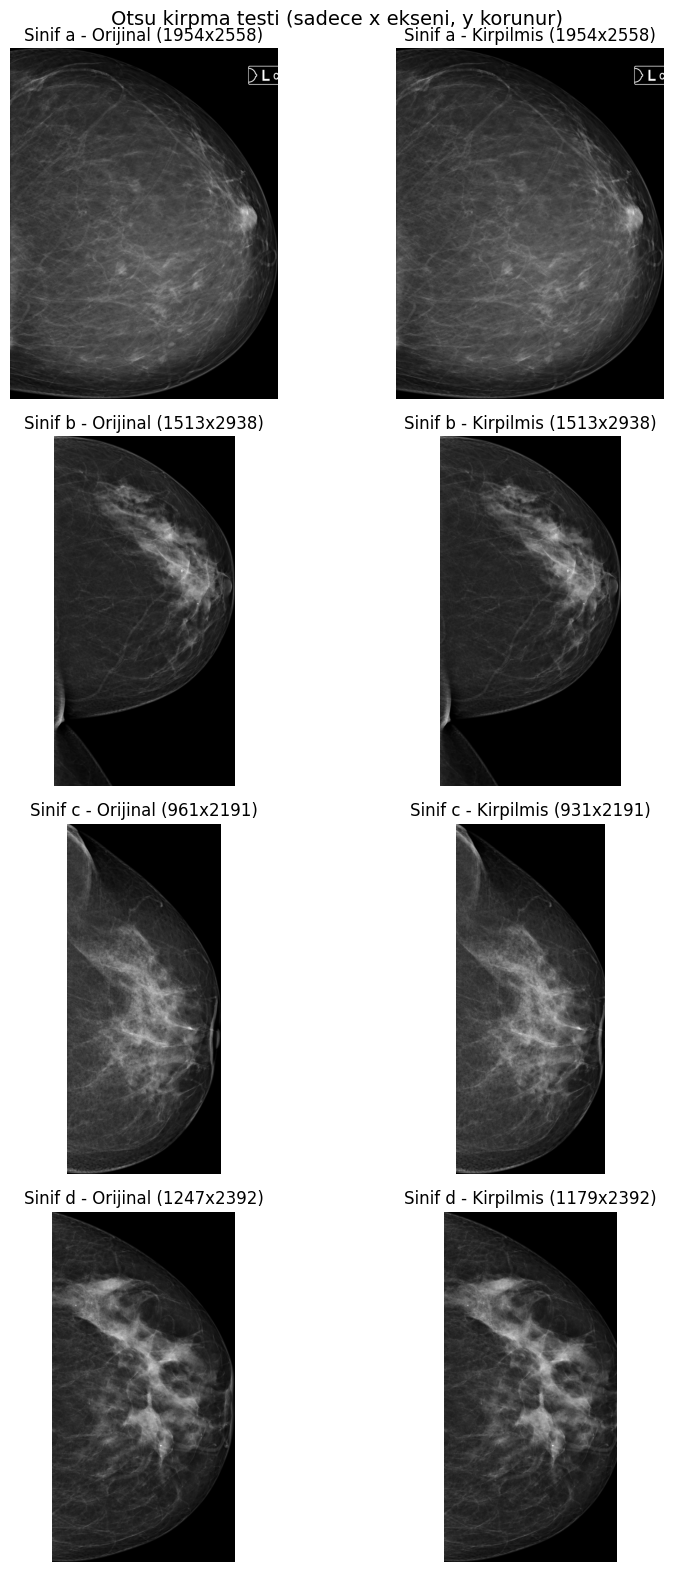

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def crop_breast_otsu(
    img_gray,
    padding_ratio=0.05,
    kernel_size=9,
    min_area_ratio=0.10,
    min_width_ratio=0.35,
):
    # Breast ROI extraction using Otsu thresholding
    # Otsu esikleme ile meme bolgesi cikarimi
    # Only the x-axis (width) is cropped; full height is preserved
    # Sadece x ekseni (genislik) kirpilir; tum yukseklik korunur
    # This guarantees the top and bottom breast tips are never cut
    # Bu, ust ve alt meme uclarinin asla kesilmemesini garanti eder
    # Original pixel intensities are never modified
    # Orijinal piksel degerleri asla degistirilmez

    h_img, w_img = img_gray.shape

    # Slight blur before threshold
    # Esiklemeden once hafif bulaniklastir
    blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)

    # Otsu threshold
    # Otsu esik
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological closing, preserves anatomy
    # Morfolojik kapatma, anatomiyi korur
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    mask = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # Largest connected component = breast
    # En buyuk bagli bilesen = meme
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels <= 1:
        return img_gray

    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    component = np.uint8(labels == largest) * 255

    # Horizontal extent of the tissue mask
    # Doku maskesinin yatay sinirlari
    ys, xs = np.where(component > 0)
    if len(xs) == 0:
        return img_gray

    x, x_max = xs.min(), xs.max()
    w = x_max - x

    # Sanity checks on width only
    # Sadece genislik uzerinde kontrol
    if w < min_width_ratio * w_img:
        return img_gray
    area_ratio = (w * (ys.max() - ys.min())) / (w_img * h_img)
    if area_ratio < min_area_ratio:
        return img_gray

    # Horizontal padding
    # Yatay pay
    pad_x = int(w * padding_ratio)
    x1 = max(0, x - pad_x)
    x2 = min(w_img, x_max + pad_x)

    # Crop only x-axis, keep full height
    # Sadece x eksenini kirp, tum yuksekligi koru
    cropped = img_gray[:, x1:x2]
    return cropped

# Test across all classes
# Tum siniflarda test et
fig, axes = plt.subplots(len(CLASSES), 2, figsize=(9, 4 * len(CLASSES)))

for row_i, cls in enumerate(CLASSES):
    cls_row = train_df[train_df["label"] == cls].iloc[0]
    img = cv2.imread(cls_row["cc_path"], cv2.IMREAD_GRAYSCALE)
    cropped = crop_breast_otsu(img)

    axes[row_i, 0].imshow(img, cmap="gray")
    axes[row_i, 0].set_title(f"Sinif {cls} - Orijinal ({img.shape[1]}x{img.shape[0]})")
    axes[row_i, 0].axis("off")

    axes[row_i, 1].imshow(cropped, cmap="gray")
    axes[row_i, 1].set_title(f"Sinif {cls} - Kirpilmis ({cropped.shape[1]}x{cropped.shape[0]})")
    axes[row_i, 1].axis("off")

plt.suptitle("Otsu kirpma testi (sadece x ekseni, y korunur)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil
from tqdm import tqdm

# Local fast disk for cropping (Colab local, not Drive)
# Kirpma icin hizli lokal disk (Colab lokal, Drive degil)
LOCAL_CROPPED = "/content/dataset_cropped"
os.makedirs(LOCAL_CROPPED, exist_ok=True)

# Final destination on Drive
# Drive uzerindeki nihai hedef
CROPPED_ROOT = "/content/drive/MyDrive/breast_density/dataset_cropped"

def process_and_save_local(src_path, label):
    # Crop and save to LOCAL disk (fast)
    # Kirp ve LOKAL diske kaydet (hizli)
    fname = os.path.basename(src_path)
    dst_dir = os.path.join(LOCAL_CROPPED, label)
    os.makedirs(dst_dir, exist_ok=True)
    dst_path = os.path.join(dst_dir, fname)

    img = cv2.imread(src_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Okunamadi, atlaniyor: {src_path}")
        return None

    cropped = crop_breast_otsu(img)
    cv2.imwrite(dst_path, cropped)
    return dst_path

# Step 1: crop everything to local disk (fast)
# Adim 1: her seyi lokal diske kirp (hizli)
print("Adim 1/2: Lokal diske kirpiliyor...")
cc_local_paths = []
mlo_local_paths = []
for _, row in tqdm(breast_df.iterrows(), total=len(breast_df)):
    cc_local_paths.append(process_and_save_local(row["cc_path"], row["label"]))
    mlo_local_paths.append(process_and_save_local(row["mlo_path"], row["label"]))

# Step 2: copy the whole folder to Drive in one bulk operation (fast)
# Adim 2: tum klasoru tek toplu islemle Drive'a kopyala (hizli)
print("\nAdim 2/2: Drive'a toplu kopyalaniyor...")
if os.path.exists(CROPPED_ROOT):
    shutil.rmtree(CROPPED_ROOT)
shutil.copytree(LOCAL_CROPPED, CROPPED_ROOT)
print("Kopyalama tamamlandi.")

# Map local paths to their Drive equivalents for the dataframe
# Tablo icin lokal yollari Drive karsiliklarina cevir
def local_to_drive(p):
    if p is None:
        return None
    return p.replace(LOCAL_CROPPED, CROPPED_ROOT)

breast_df["cc_path_cropped"] = [local_to_drive(p) for p in cc_local_paths]
breast_df["mlo_path_cropped"] = [local_to_drive(p) for p in mlo_local_paths]

# Verify
# Dogrula
n_missing = breast_df["cc_path_cropped"].isna().sum() + breast_df["mlo_path_cropped"].isna().sum()
print(f"\nEksik/basarisiz kayit: {n_missing}")

# Save updated split table
# Guncellenmis split tablosunu kaydet
split_save_path = os.path.join(OUTPUT_ROOT, "breast_split_cropped.csv")
breast_df.to_csv(split_save_path, index=False)
print(f"Guncellenmis tablo kaydedildi: {split_save_path}")

Adim 1/2: Lokal diske kirpiliyor...


100%|██████████| 4000/4000 [2:25:44<00:00,  2.19s/it]



Adim 2/2: Drive'a toplu kopyalaniyor...
Kopyalama tamamlandi.

Eksik/basarisiz kayit: 0
Guncellenmis tablo kaydedildi: /content/drive/MyDrive/breast_density/outputs/breast_split_cropped.csv


### TwoViewDensityNet

In [ ]:
import pandas as pd
import os

# Reload the saved split table with cropped paths
# Kirpilmis yollarla kaydedilmis split tablosunu tekrar yukle
split_save_path = os.path.join(OUTPUT_ROOT, "breast_split_cropped.csv")
breast_df = pd.read_csv(split_save_path)

print("Split tablosu yuklendi.")
print(breast_df["split"].value_counts())
print("Sutunlar:", breast_df.columns.tolist())

Split tablosu yuklendi.
split
train    2856
val       572
test      572
Name: count, dtype: int64
Sutunlar: ['patient_id', 'side', 'label', 'cc_path', 'mlo_path', 'label_idx', 'split', 'cc_path_cropped', 'mlo_path_cropped']


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2

class BreastDensityDataset(Dataset):
    # Two-view breast density dataset using cropped images
    # Kirpilmis goruntulerle iki gorunumlu meme yogunlugu veri seti
    # Returns (cc_image, mlo_image, label)
    # (cc_goruntu, mlo_goruntu, etiket) dondurur

    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _load_image(self, path):
        # Read grayscale, convert to 3-channel for ImageNet backbone
        # Gri tonlamali oku, ImageNet omurgasi icin 3 kanala cevir
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Goruntu okunamadi: {path}")
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Use cropped paths
        # Kirpilmis yollari kullan
        cc_img = self._load_image(row["cc_path_cropped"])
        mlo_img = self._load_image(row["mlo_path_cropped"])

        cc_img = self.transform(image=cc_img)["image"]
        mlo_img = self.transform(image=mlo_img)["image"]

        label = int(row["label_idx"])
        return cc_img, mlo_img, label

# Batch size for 512x512 two-view full fine-tune on T4
# T4 uzerinde 512x512 iki gorunum tam fine-tune icin batch boyutu
BATCH_SIZE = 8
NUM_WORKERS = 2

# Split dataframes
# Split tablolari
train_df = breast_df[breast_df["split"] == "train"].copy()
val_df = breast_df[breast_df["split"] == "val"].copy()
test_df = breast_df[breast_df["split"] == "test"].copy()

# Datasets
# Veri setleri
train_ds = BreastDensityDataset(train_df, train_transform)
val_ds = BreastDensityDataset(val_df, eval_transform)
test_ds = BreastDensityDataset(test_df, eval_transform)

# DataLoaders
# Veri yukleyiciler
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

print("DataLoader'lar hazir (kirpilmis goruntulerle).")
print(f"Train: {len(train_ds)} ornek, {len(train_loader)} batch")
print(f"Val:   {len(val_ds)} ornek, {len(val_loader)} batch")
print(f"Test:  {len(test_ds)} ornek, {len(test_loader)} batch")

# Sanity check
# Hizli kontrol
cc, mlo, lbl = next(iter(train_loader))
print(f"\nCC: {cc.shape}, MLO: {mlo.shape}, etiket: {lbl[:8].tolist()}")

DataLoader'lar hazir (kirpilmis goruntulerle).
Train: 2856 ornek, 357 batch
Val:   572 ornek, 72 batch
Test:  572 ornek, 72 batch

CC: torch.Size([8, 3, 512, 512]), MLO: torch.Size([8, 3, 512, 512]), etiket: [3, 0, 3, 2, 3, 2, 3, 3]


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import torch.nn.functional as F

@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes=4):
    # Run model over a loader, return loss and metrics
    # Modeli bir loader uzerinde calistir, loss ve metrikleri dondur
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    for cc, mlo, labels in loader:
        cc = cc.to(device)
        mlo = mlo.to(device)
        labels = labels.to(device)

        outputs = model(cc, mlo)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * labels.size(0)

        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    per_class_f1 = f1_score(all_labels, all_preds, average=None, labels=list(range(num_classes)))

    # ROC-AUC (one-vs-rest, macro). Guard against missing classes.
    # ROC-AUC (bire-karsi-hepsi, macro). Eksik sinif durumuna karsi koru.
    try:
        macro_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
    except ValueError:
        macro_auc = float("nan")

    metrics = {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "macro_auc": macro_auc,
    }
    for i in range(num_classes):
        metrics[f"f1_{CLASSES[i]}"] = per_class_f1[i]

    return metrics, all_labels, all_preds, all_probs

print("Metrik fonksiyonu hazir.")

Metrik fonksiyonu hazir.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
import pandas as pd

# Directories for checkpoints and logs on Drive
# Drive uzerinde checkpoint ve log dizinleri
CKPT_DIR = os.path.join(OUTPUT_ROOT, "twoviewdensitynet")
os.makedirs(CKPT_DIR, exist_ok=True)

LAST_CKPT = os.path.join(CKPT_DIR, "last.pt")
BEST_CKPT = os.path.join(CKPT_DIR, "best.pt")
EXCEL_LOG = os.path.join(CKPT_DIR, "training_log.xlsx")

# Instantiate model
# Modeli olustur
model = TwoViewDensityNet(num_classes=4, pretrained=True).to(device)

# AdamW optimizer, full fine-tune
# AdamW optimizer, tam fine-tune
LR = 1e-4
WEIGHT_DECAY = 1e-4
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Cosine annealing scheduler over total epochs
# Toplam epoch boyunca cosine annealing scheduler
MAX_EPOCHS = 50
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

# Early stopping patience
# Early stopping sabri
PATIENCE = 10

def save_checkpoint(path, epoch, model, optimizer, scheduler, best_val_loss, epochs_no_improve):
    # Save full training state for resume
    # Devam icin tum egitim durumunu kaydet
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_loss": best_val_loss,
        "epochs_no_improve": epochs_no_improve,
    }, path)

def load_checkpoint(path, model, optimizer, scheduler):
    # Load training state to resume
    # Devam etmek icin egitim durumunu yukle
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    return ckpt["epoch"], ckpt["best_val_loss"], ckpt["epochs_no_improve"]

# Resume logic: if last.pt exists, continue from it
# Devam mantigi: last.pt varsa oradan devam et
start_epoch = 0
best_val_loss = float("inf")
epochs_no_improve = 0

if os.path.exists(LAST_CKPT):
    start_epoch, best_val_loss, epochs_no_improve = load_checkpoint(
        LAST_CKPT, model, optimizer, scheduler
    )
    start_epoch += 1  # continue from next epoch
    print(f"Checkpoint bulundu. Epoch {start_epoch}'dan devam ediliyor.")
    print(f"En iyi val loss: {best_val_loss:.4f}, iyilesmeyen epoch: {epochs_no_improve}")
else:
    print("Checkpoint yok. Sifirdan baslaniyor.")

print("Egitim kurulumu hazir.")

Checkpoint bulundu. Epoch 15'dan devam ediliyor.
En iyi val loss: 0.1209, iyilesmeyen epoch: 5
Egitim kurulumu hazir.


In [ ]:
from tqdm import tqdm
import pandas as pd

# Load existing log if resuming, else start fresh
# Devam ediliyorsa mevcut logu yukle, yoksa yeniden basla
if os.path.exists(EXCEL_LOG):
    log_df = pd.read_excel(EXCEL_LOG)
    log_rows = log_df.to_dict("records")
else:
    log_rows = []

def train_one_epoch(model, loader, criterion, optimizer, device):
    # One training epoch
    # Bir egitim epoch'u
    model.train()
    total_loss = 0.0
    for cc, mlo, labels in tqdm(loader, desc="Train", leave=False):
        cc = cc.to(device)
        mlo = mlo.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(cc, mlo)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
    return total_loss / len(loader.dataset)

# Main training loop
# Ana egitim dongusu
print(f"Egitim basliyor. Epoch {start_epoch} -> {MAX_EPOCHS - 1}\n")

for epoch in range(start_epoch, MAX_EPOCHS):
    # Train
    # Egit
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Evaluate on train (for metrics) and val
    # Train (metrikler icin) ve val uzerinde degerlendir
    train_metrics, _, _, _ = evaluate(model, train_loader, criterion, device)
    val_metrics, _, _, _ = evaluate(model, val_loader, criterion, device)

    # Step scheduler
    # Scheduler adimi
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    # Print summary
    # Ozet yazdir
    print(f"Epoch {epoch:02d} | "
          f"train_loss {train_metrics['loss']:.4f} acc {train_metrics['accuracy']:.3f} f1 {train_metrics['macro_f1']:.3f} | "
          f"val_loss {val_metrics['loss']:.4f} acc {val_metrics['accuracy']:.3f} f1 {val_metrics['macro_f1']:.3f} | "
          f"lr {current_lr:.2e}")

    # Build log row with train and val metrics
    # Train ve val metrikleriyle log satiri olustur
    row = {"epoch": epoch, "lr": current_lr}
    for k, v in train_metrics.items():
        row[f"train_{k}"] = v
    for k, v in val_metrics.items():
        row[f"val_{k}"] = v
    log_rows.append(row)

    # Save Excel log every epoch
    # Her epoch Excel logunu kaydet
    pd.DataFrame(log_rows).to_excel(EXCEL_LOG, index=False)

    # Check for improvement (based on val loss)
    # Iyilesme kontrolu (val loss temelli)
    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        epochs_no_improve = 0
        save_checkpoint(BEST_CKPT, epoch, model, optimizer, scheduler, best_val_loss, epochs_no_improve)
        print(f"  -> Yeni en iyi val loss: {best_val_loss:.4f}, best.pt kaydedildi")
    else:
        epochs_no_improve += 1
        print(f"  -> Iyilesme yok ({epochs_no_improve}/{PATIENCE})")

    # Always save last checkpoint for resume
    # Devam icin her zaman son checkpoint'i kaydet
    save_checkpoint(LAST_CKPT, epoch, model, optimizer, scheduler, best_val_loss, epochs_no_improve)

    # Early stopping
    # Erken durdurma
    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping: {PATIENCE} epoch boyunca iyilesme yok. Egitim durduruluyor.")
        break

print("\nEgitim tamamlandi.")
print(f"En iyi val loss: {best_val_loss:.4f}")

Egitim basliyor. Epoch 15 -> 49



Epoch 15 | train_loss 0.0735 acc 0.800 f1 0.804 | val_loss 0.1971 acc 0.678 f1 0.684 | lr 7.68e-05
  -> Iyilesme yok (6/10)


Epoch 16 | train_loss 0.0925 acc 0.751 f1 0.752 | val_loss 0.2668 acc 0.666 f1 0.667 | lr 7.41e-05
  -> Iyilesme yok (7/10)


Epoch 17 | train_loss 0.0522 acc 0.786 f1 0.787 | val_loss 0.1531 acc 0.699 f1 0.700 | lr 7.13e-05
  -> Iyilesme yok (8/10)


Epoch 18 | train_loss 0.0373 acc 0.824 f1 0.825 | val_loss 0.1466 acc 0.671 f1 0.678 | lr 6.84e-05
  -> Iyilesme yok (9/10)


Epoch 19 | train_loss 0.0377 acc 0.846 f1 0.854 | val_loss 0.1737 acc 0.678 f1 0.683 | lr 6.55e-05
  -> Iyilesme yok (10/10)

Early stopping: 10 epoch boyunca iyilesme yok. Egitim durduruluyor.

Egitim tamamlandi.
En iyi val loss: 0.1209


In [ ]:
import torch
from sklearn.metrics import classification_report, confusion_matrix

# Load best checkpoint (lowest val loss)
# En iyi checkpoint'i yukle (en dusuk val loss)
ckpt = torch.load(BEST_CKPT, map_location=device)
model.load_state_dict(ckpt["model_state"])
print(f"En iyi model yuklendi (epoch {ckpt['epoch']}, val_loss {ckpt['best_val_loss']:.4f})")

# Evaluate on test set
# Test setinde degerlendir
test_metrics, test_labels, test_preds, test_probs = evaluate(model, test_loader, criterion, device)

print("\nTEST SONUCLARI")
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Macro F1:  {test_metrics['macro_f1']:.4f}")
print(f"Macro AUC: {test_metrics['macro_auc']:.4f}")
print("\nPer-class F1:")
for c in CLASSES:
    print(f"  {c}: {test_metrics[f'f1_{c}']:.4f}")

# Detailed classification report
# Detayli siniflandirma raporu
print("\nSiniflandirma Raporu")
print(classification_report(test_labels, test_preds, target_names=CLASSES, digits=3))

En iyi model yuklendi (epoch 9, val_loss 0.1209)

TEST SONUCLARI
Accuracy:  0.6748
Macro F1:  0.6705
Macro AUC: 0.9121

Per-class F1:
  a: 0.5895
  b: 0.6485
  c: 0.7088
  d: 0.7354

Siniflandirma Raporu
              precision    recall  f1-score   support

           a      0.475     0.778     0.589        72
           b      0.680     0.620     0.649       192
           c      0.849     0.608     0.709       212
           d      0.646     0.854     0.735        96

    accuracy                          0.675       572
   macro avg      0.662     0.715     0.671       572
weighted avg      0.711     0.675     0.678       572



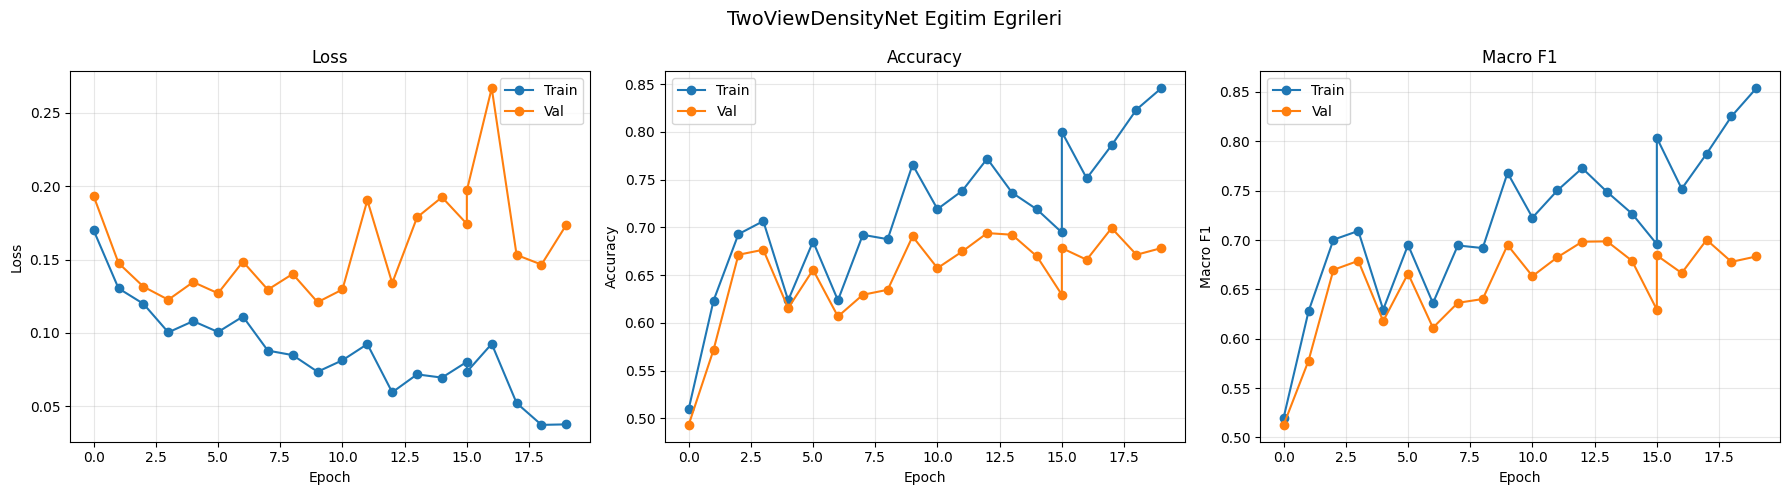

Grafik kaydedildi: /content/drive/MyDrive/breast_density/outputs/twoviewdensitynet/training_curves.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the Excel training log
# Excel egitim logunu oku
log_df = pd.read_excel(EXCEL_LOG)

# Plot train vs val for key metrics, side by side
# Anahtar metrikler icin train vs val, yan yana
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(log_df["epoch"], log_df["train_loss"], marker="o", label="Train")
axes[0].plot(log_df["epoch"], log_df["val_loss"], marker="o", label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(log_df["epoch"], log_df["train_accuracy"], marker="o", label="Train")
axes[1].plot(log_df["epoch"], log_df["val_accuracy"], marker="o", label="Val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Macro F1
axes[2].plot(log_df["epoch"], log_df["train_macro_f1"], marker="o", label="Train")
axes[2].plot(log_df["epoch"], log_df["val_macro_f1"], marker="o", label="Val")
axes[2].set_title("Macro F1")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Macro F1")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("TwoViewDensityNet Egitim Egrileri", fontsize=14)
plt.tight_layout()

# Save figure to Drive
# Grafigi Drive'a kaydet
fig_path = os.path.join(CKPT_DIR, "training_curves.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Grafik kaydedildi: {fig_path}")

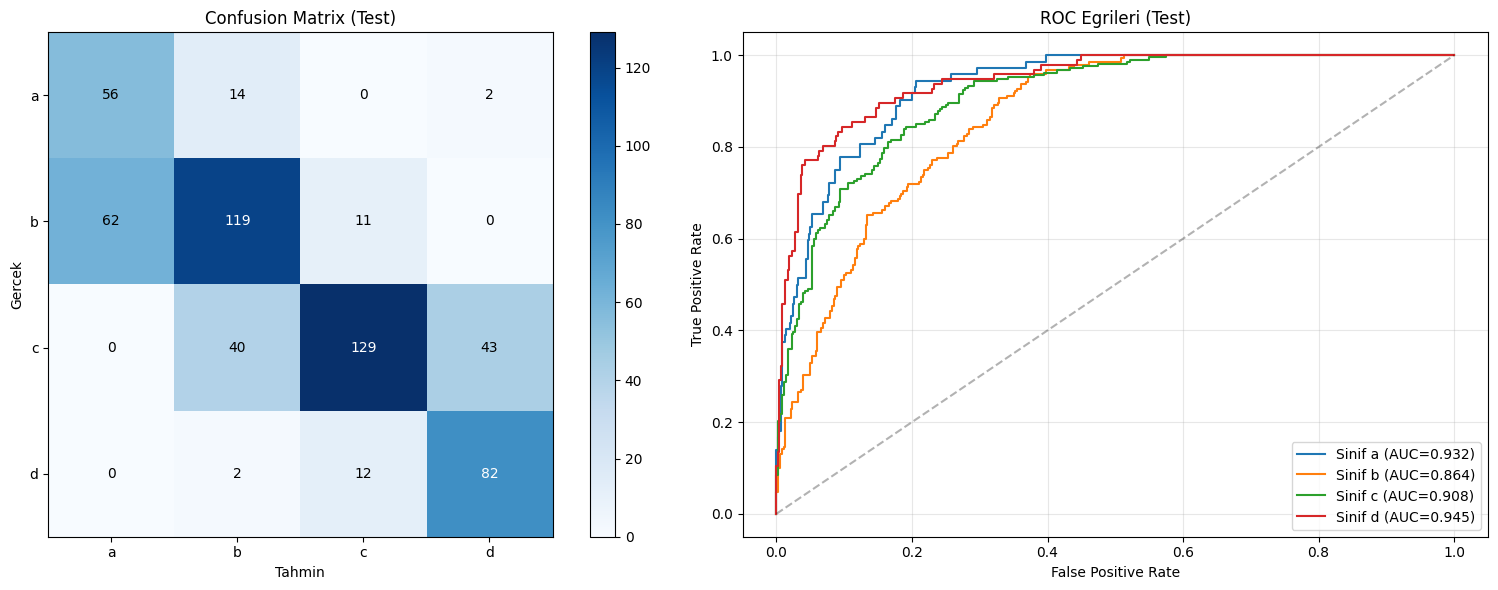

Grafik kaydedildi: /content/drive/MyDrive/breast_density/outputs/twoviewdensitynet/test_confusion_roc.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
# Karisiklik matrisi
cm = confusion_matrix(test_labels, test_preds)
im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion Matrix (Test)")
axes[0].set_xlabel("Tahmin")
axes[0].set_ylabel("Gercek")
axes[0].set_xticks(range(len(CLASSES)))
axes[0].set_yticks(range(len(CLASSES)))
axes[0].set_xticklabels(CLASSES)
axes[0].set_yticklabels(CLASSES)
# Annotate counts
# Sayilari yaz
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=axes[0])

# ROC curves (one-vs-rest per class)
# ROC egrileri (sinif basina bire-karsi-hepsi)
test_labels_bin = label_binarize(test_labels, classes=list(range(len(CLASSES))))
for i, c in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(test_labels_bin[:, i], test_probs[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f"Sinif {c} (AUC={roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_title("ROC Egrileri (Test)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Save
# Kaydet
fig_path = os.path.join(CKPT_DIR, "test_confusion_roc.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Grafik kaydedildi: {fig_path}")

### TwoViewDensityNet_V2

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

IMG_SIZE = 512
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Stronger augmentation to fight overfitting
# Overfitting ile savasmak icin daha guclu augmentation
# Higher probabilities and CoarseDropout added
# Daha yuksek olasiliklar ve CoarseDropout eklendi
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.0625,
        scale_limit=0.1,
        rotate_limit=15,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.7
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.5
    ),
    # Randomly erase small patches to discourage memorization
    # Ezberi zorlastirmak icin rastgele kucuk parcalar sil
    A.CoarseDropout(
        max_holes=8,
        max_height=int(IMG_SIZE * 0.1),
        max_width=int(IMG_SIZE * 0.1),
        fill_value=0,
        p=0.3
    ),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

print("Guclendirilmis augmentation hazir.")

Guclendirilmis augmentation hazir.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_820/360628424.py:30: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


In [ ]:
import torch
import numpy as np

# Softened class weights using square root of inverse frequency
# Ters frekansin karekoku ile yumusatilmis sinif agirliklari
class_counts = train_df["label_idx"].value_counts().sort_index().values
print("Egitim sinif sayilari (a,b,c,d):", class_counts)

# Square root softening: less aggressive than pure inverse frequency
# Karekok yumusatma: saf ters frekanstan daha az agresif
inv_freq = 1.0 / class_counts
soft_weights = np.sqrt(inv_freq)
soft_weights = soft_weights / soft_weights.sum() * len(class_counts)
alpha = torch.tensor(soft_weights, dtype=torch.float32).to(device)

print("Yumusatilmis alpha (a,b,c,d):", alpha.cpu().numpy().round(3))

# Focal loss with softened alpha (FocalLoss class already defined)
# Yumusatilmis alpha ile focal loss (FocalLoss sinifi zaten tanimli)
criterion = FocalLoss(gamma=2.0, alpha=alpha)
print("Yumusatilmis focal loss hazir.")

Egitim sinif sayilari (a,b,c,d): [ 358 1016  988  494]
Yumusatilmis alpha (a,b,c,d): [1.313 0.779 0.79  1.118]
Yumusatilmis focal loss hazir.


In [ ]:
import torch
import torch.optim as optim
import os

# New output directory for v2 experiment
# v2 deneyi icin yeni cikti dizini
CKPT_DIR = os.path.join(OUTPUT_ROOT, "twoviewdensitynet_v2")
os.makedirs(CKPT_DIR, exist_ok=True)

LAST_CKPT = os.path.join(CKPT_DIR, "last.pt")
BEST_CKPT = os.path.join(CKPT_DIR, "best.pt")
EXCEL_LOG = os.path.join(CKPT_DIR, "training_log.xlsx")

# Fresh model with higher dropout in classifier
# Classifier'da daha yuksek dropout ile yeni model
# We modify the model to use dropout 0.6, so redefine here
# Modeli dropout 0.6 kullanacak sekilde burada yeniden tanimla
class TwoViewDensityNetV2(nn.Module):
    def __init__(self, num_classes=4, pretrained=True, dropout=0.6):
        super().__init__()
        cc_backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        )
        self.cc_features = nn.Sequential(*list(cc_backbone.children())[:-1])

        mlo_backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        )
        self.mlo_features = nn.Sequential(*list(mlo_backbone.children())[:-1])

        feat_dim = 2048
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout - 0.1),
            nn.Linear(512, num_classes)
        )

    def forward(self, cc, mlo):
        cc_feat = torch.flatten(self.cc_features(cc), 1)
        mlo_feat = torch.flatten(self.mlo_features(mlo), 1)
        combined = torch.cat([cc_feat, mlo_feat], dim=1)
        return self.classifier(combined)

model = TwoViewDensityNetV2(num_classes=4, pretrained=True, dropout=0.6).to(device)

# Lower LR and higher weight decay for regularization
# Duzenlilestirme icin dusuk LR ve yuksek weight decay
LR = 5e-5
WEIGHT_DECAY = 1e-3
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

MAX_EPOCHS = 50
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
PATIENCE = 10

# Checkpoint helpers (same as before)
# Checkpoint yardimcilari (oncekiyle ayni)
def save_checkpoint(path, epoch, model, optimizer, scheduler, best_val_loss, epochs_no_improve):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_loss": best_val_loss,
        "epochs_no_improve": epochs_no_improve,
    }, path)

def load_checkpoint(path, model, optimizer, scheduler):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    return ckpt["epoch"], ckpt["best_val_loss"], ckpt["epochs_no_improve"]

# Resume logic
# Devam mantigi
start_epoch = 0
best_val_loss = float("inf")
epochs_no_improve = 0

if os.path.exists(LAST_CKPT):
    start_epoch, best_val_loss, epochs_no_improve = load_checkpoint(LAST_CKPT, model, optimizer, scheduler)
    start_epoch += 1
    print(f"v2 checkpoint bulundu. Epoch {start_epoch}'dan devam ediliyor.")
else:
    print("v2 sifirdan baslaniyor.")

print("v2 kurulumu hazir (dropout 0.6, LR 5e-5, weight_decay 1e-3).")

v2 sifirdan baslaniyor.
v2 kurulumu hazir (dropout 0.6, LR 5e-5, weight_decay 1e-3).


In [ ]:
from tqdm import tqdm
import pandas as pd

# Load existing log if resuming, else start fresh
# Devam ediliyorsa mevcut logu yukle, yoksa yeniden basla
if os.path.exists(EXCEL_LOG):
    log_df = pd.read_excel(EXCEL_LOG)
    log_rows = log_df.to_dict("records")
else:
    log_rows = []

def train_one_epoch(model, loader, criterion, optimizer, device):
    # One training epoch
    # Bir egitim epoch'u
    model.train()
    total_loss = 0.0
    for cc, mlo, labels in tqdm(loader, desc="Train", leave=False):
        cc = cc.to(device)
        mlo = mlo.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(cc, mlo)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
    return total_loss / len(loader.dataset)

# Main training loop
# Ana egitim dongusu
print(f"Egitim basliyor. Epoch {start_epoch} -> {MAX_EPOCHS - 1}\n")

for epoch in range(start_epoch, MAX_EPOCHS):
    # Train
    # Egit
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Evaluate on train and val
    # Train ve val uzerinde degerlendir
    train_metrics, _, _, _ = evaluate(model, train_loader, criterion, device)
    val_metrics, _, _, _ = evaluate(model, val_loader, criterion, device)

    # Step scheduler
    # Scheduler adimi
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    # Print summary
    # Ozet yazdir
    print(f"Epoch {epoch:02d} | "
          f"train_loss {train_metrics['loss']:.4f} acc {train_metrics['accuracy']:.3f} f1 {train_metrics['macro_f1']:.3f} | "
          f"val_loss {val_metrics['loss']:.4f} acc {val_metrics['accuracy']:.3f} f1 {val_metrics['macro_f1']:.3f} | "
          f"lr {current_lr:.2e}")

    # Build log row
    # Log satiri olustur
    row = {"epoch": epoch, "lr": current_lr}
    for k, v in train_metrics.items():
        row[f"train_{k}"] = v
    for k, v in val_metrics.items():
        row[f"val_{k}"] = v
    log_rows.append(row)

    # Save Excel log every epoch
    # Her epoch Excel logunu kaydet
    pd.DataFrame(log_rows).to_excel(EXCEL_LOG, index=False)

    # Check improvement based on val loss
    # Val loss temelli iyilesme kontrolu
    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        epochs_no_improve = 0
        save_checkpoint(BEST_CKPT, epoch, model, optimizer, scheduler, best_val_loss, epochs_no_improve)
        print(f"  -> Yeni en iyi val loss: {best_val_loss:.4f}, best.pt kaydedildi")
    else:
        epochs_no_improve += 1
        print(f"  -> Iyilesme yok ({epochs_no_improve}/{PATIENCE})")

    # Always save last checkpoint for resume
    # Devam icin her zaman son checkpoint'i kaydet
    save_checkpoint(LAST_CKPT, epoch, model, optimizer, scheduler, best_val_loss, epochs_no_improve)

    # Early stopping
    # Erken durdurma
    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping: {PATIENCE} epoch boyunca iyilesme yok. Egitim durduruluyor.")
        break

print("\nEgitim tamamlandi.")
print(f"En iyi val loss: {best_val_loss:.4f}")

NameError: name 'os' is not defined